In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [ ]:
tpath1 = "D:\\Nicole Lee - HDD\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Worm tracking\\ML\\"
filename = "20230307 WT Blue"
genotype = "WT_Blue"
tpath = tpath1 + filename + "\\"

# Individual plots

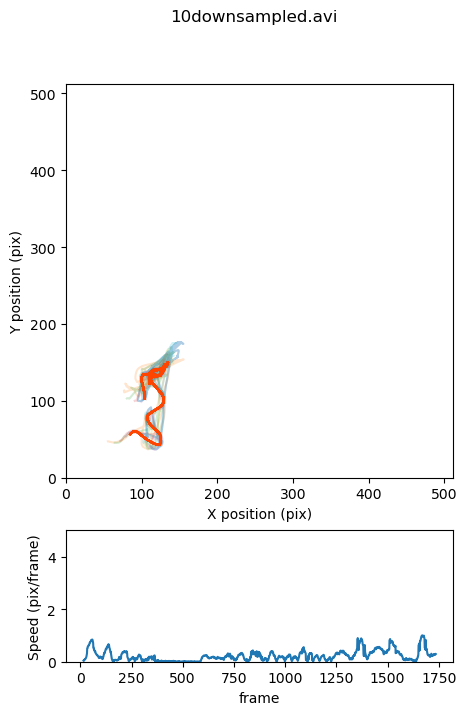

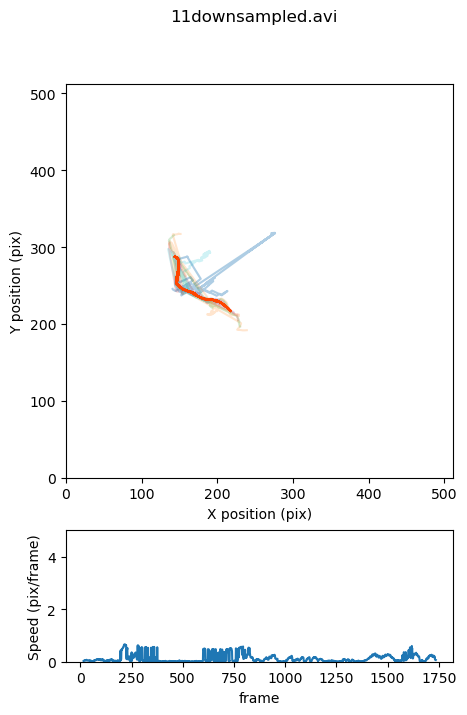

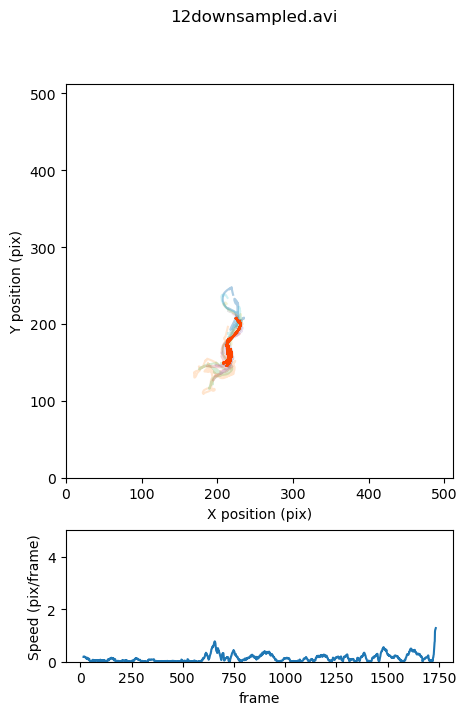

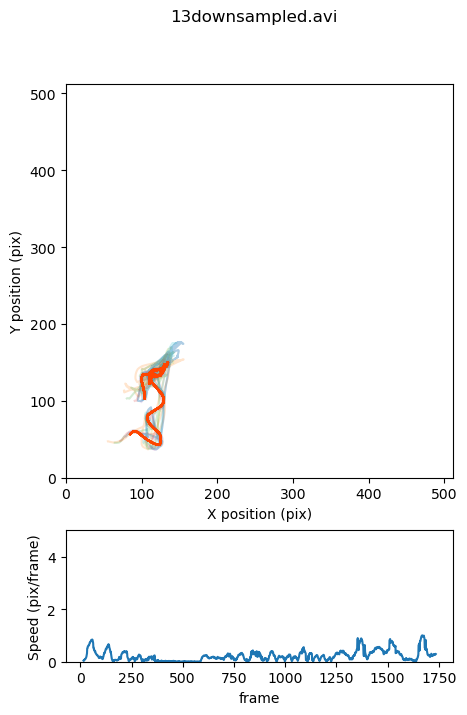

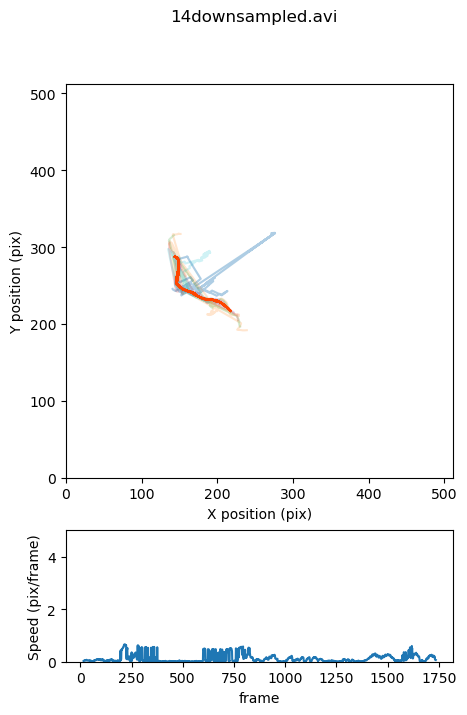

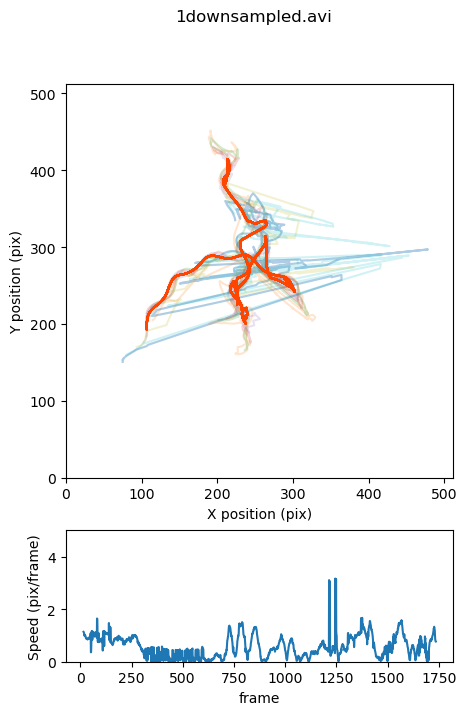

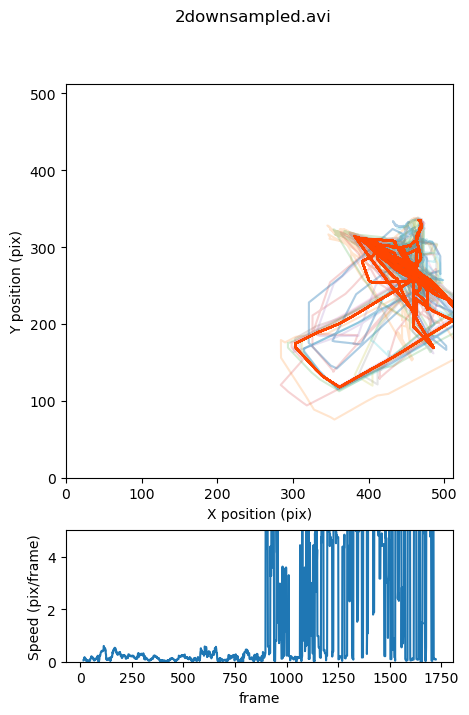

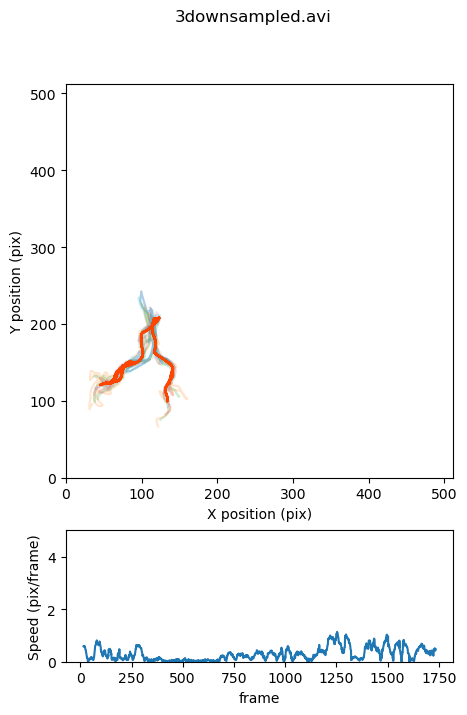

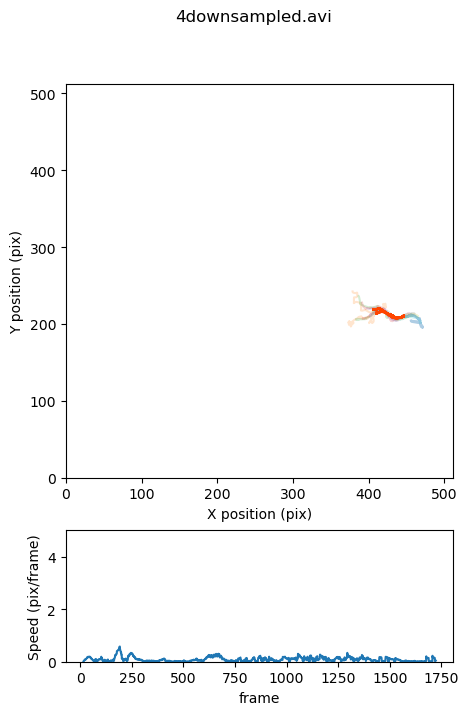

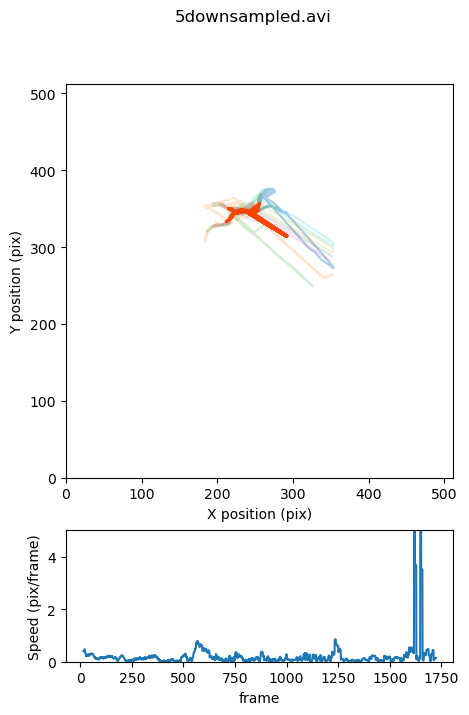

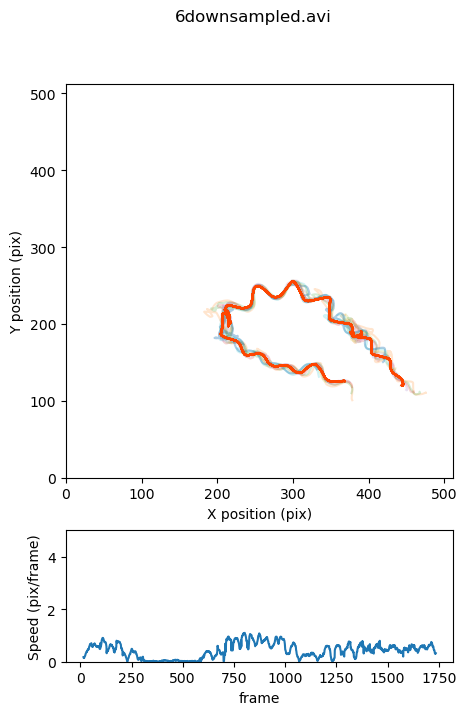

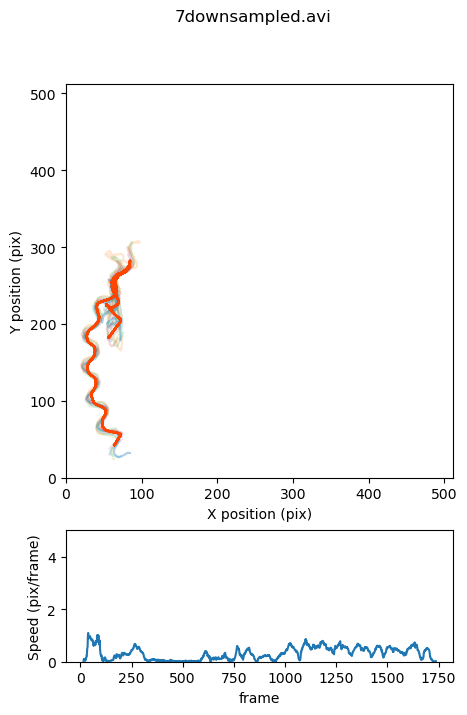

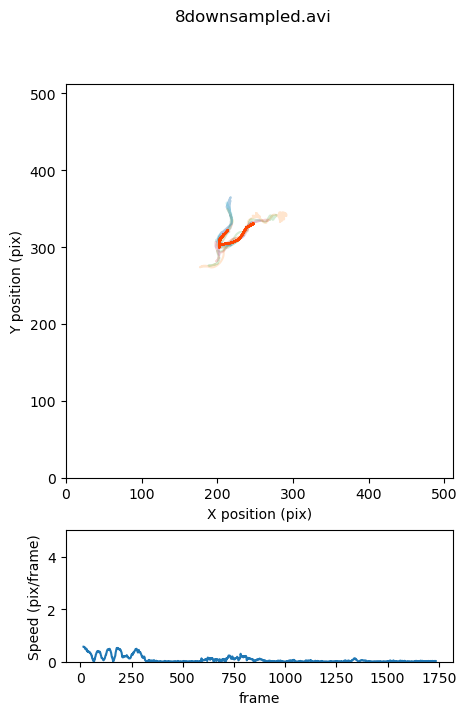

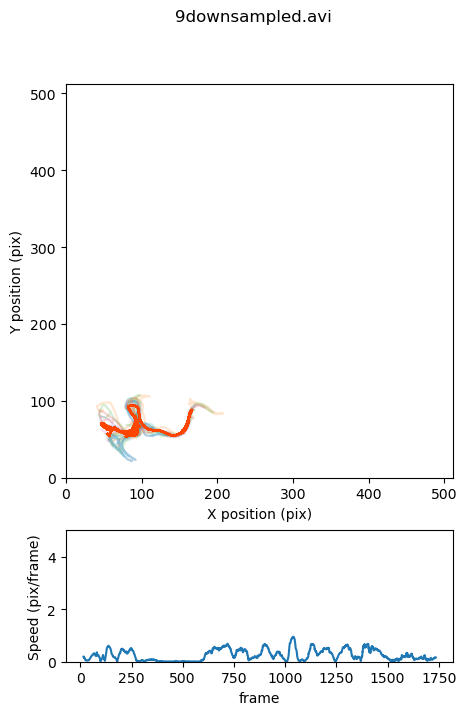

In [ ]:
Path = tpath
rollingAverageWindow = 30
if 'images' not in os.listdir(Path):
    os.makedirs(os.path.join(Path, 'images'))
trainingList = [f for f in os.listdir(Path) if '.csv' in f]
for f in trainingList:
    traces = pd.read_csv(os.path.join(Path, f))
    traces.columns = [traces.columns[i]+ '_' + traces.iloc[0, i]+ '_' +  traces.iloc[1, i] for i in range(len(traces.columns))]
    traces = traces.drop([0, 1], axis = 0).reset_index().drop('index', axis = 1).rename(columns = {'scorer_bodyparts_coords':'frame'} ).astype('float').round(2)
    traces = traces.rolling(rollingAverageWindow).mean()
    test = traces.iloc[:,10:19] #only looking at middle 3 points
    dftest = test[test.columns.drop(list(test.filter(regex='likelihood.*')))]
    tr = pd.DataFrame()
    tr['frame'] = traces['frame']
    tr['second'] = tr['frame']/30
    tr['meanX'] = dftest.filter(regex = '_x').mean(axis = 1)
    tr['meanY'] = dftest.filter(regex = '_y').mean(axis = 1)
    tr['meanSpeed'] = np.sqrt(np.square(tr['meanX'].diff())+np.square(tr['meanY'].diff()))
    fig, axes = plt.subplots(2, 1, figsize = (5, 7.5), gridspec_kw={'height_ratios': [3, 1]})
    for i in range(len(traces.columns)):
        axes[0].plot(traces.filter(regex = str(i)+'_x'), traces.filter(regex = str(i)+'_y'), alpha = 0.2)
        axes[0].plot(tr['meanX'], tr['meanY'], 'orangered')
    axes[1].plot(tr['frame'], tr['meanSpeed'])
    axes[0].set_xlabel('X position (pix)')    
    axes[0].set_ylabel('Y position (pix)')
    axes[0].set_xlim(0, 512)    
    axes[0].set_ylim(0, 512)
    axes[1].set_xlabel('frame')    
    axes[1].set_ylabel('Speed (pix/frame)')
    axes[1].set_ylim([0, 5.0])   

    fig.suptitle(f.split('DLC')[0]+'.avi')
    fig.savefig(os.path.join(Path, 'images',  f +'trajectorySpeedPlot.png'), dpi = 300)
    fig.savefig(os.path.join(Path, 'images',  f +'trajectorySpeedPlot.svg'))
    meandata = tr[['second', 'frame', 'meanX', 'meanY', 'meanSpeed']]


# making CSV

In [ ]:
Path = tpath
rollingAverageWindow = 30
if 'images' not in os.listdir(Path):
    os.makedirs(os.path.join(Path, 'images'))
    

trainingList = [f for f in os.listdir(Path) if '.csv' in f]
dftest = pd.DataFrame()
for f in trainingList:
    traces = pd.read_csv(os.path.join(Path, f))
    title = f.split("downsampled")[0]
    traces.columns = [title+ '_' + traces.iloc[0, i]+ '_' +  traces.iloc[1, i] for i in range(len(traces.columns))]
    traces = traces.drop([0, 1], axis = 0).reset_index().drop('index', axis = 1).astype('float').round(2)
    traces = traces.rename(columns = {traces.columns[0]: "frame"})
    traces = traces[traces.columns.drop(list(traces.filter(regex='likelihood.*')))]
    traces = traces.rolling(rollingAverageWindow).mean()
    traces = traces.iloc[29:]
    dftest = pd.concat([dftest, traces], axis = 1)

dftest = dftest.loc[:,~dftest.columns.duplicated()].reset_index(drop=True)

dftest

,frame,WT_Blue_1x_1_bodypart1_x,WT_Blue_1x_1_bodypart1_y,WT_Blue_1x_1_bodypart2_x,WT_Blue_1x_1_bodypart2_y,WT_Blue_1x_1_bodypart3_x,WT_Blue_1x_1_bodypart3_y,WT_Blue_1x_1_bodypart4_x,WT_Blue_1x_1_bodypart4_y,WT_Blue_1x_1_bodypart5_x,...,WT_Blue_half_6_bodypart6_x,WT_Blue_half_6_bodypart6_y,WT_Blue_half_6_bodypart7_x,WT_Blue_half_6_bodypart7_y,WT_Blue_half_6_bodypart8_x,WT_Blue_half_6_bodypart8_y,WT_Blue_half_6_bodypart9_x,WT_Blue_half_6_bodypart9_y,WT_Blue_half_6_bodypart10_x,WT_Blue_half_6_bodypart10_y
0,14.5,255.347000,75.947000,245.429667,80.975000,236.784667,75.685000,231.492667,68.418333,226.158000,...,96.359000,127.437667,96.716000,127.847000,98.883667,128.853667,101.350000,128.312000,110.884667,101.394333
1,15.5,255.167000,76.421333,245.247333,81.001667,236.715000,75.572000,231.463333,68.280000,226.095333,...,96.237667,127.169000,96.800333,127.382000,99.326667,127.595333,102.020000,126.581000,110.884667,100.992333
2,16.5,254.995333,76.916333,245.072667,81.019000,236.657667,75.447667,231.461667,68.119667,226.037000,...,96.110333,126.894000,96.876333,126.881333,99.767000,126.327667,102.684667,124.847667,110.868333,100.591000
3,17.5,254.811667,77.411333,244.912667,81.035000,236.608333,75.323000,231.448000,67.982000,225.981667,...,95.960333,126.602000,96.920333,126.319333,100.180667,125.044000,103.330667,123.112000,110.844667,100.191000
4,18.5,254.604333,77.921000,244.750667,81.021667,236.553667,75.186000,231.437000,67.823000,225.908333,...,95.801333,126.289667,96.967667,125.729000,100.609000,123.740000,103.999000,121.356667,111.555667,97.904667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1718,1732.5,200.801000,78.291667,193.290000,86.746333,185.831667,88.622000,179.823000,89.183667,179.281000,...,55.945667,237.256333,57.302333,232.310000,56.125000,228.452667,51.792333,226.560000,45.884333,225.038667
1719,1733.5,200.574333,78.427667,193.089667,86.668000,185.818333,88.382667,179.871667,89.044333,179.467333,...,55.775000,237.442667,57.333333,232.565000,56.323333,228.664333,52.168000,226.791000,46.194000,225.327000
1720,1734.5,200.398333,78.534000,192.926667,86.586667,185.815000,88.161333,179.981333,88.919333,179.644333,...,55.553000,237.634333,57.339333,232.824333,56.520667,228.907333,52.577000,227.048000,46.547667,225.624000
1721,1735.5,200.201000,78.653000,192.753667,86.509000,185.798000,87.947000,180.068333,88.789000,179.812667,...,55.332333,237.823667,57.325333,233.096000,56.704667,229.161333,52.986667,227.309000,46.918333,225.908333


In [ ]:
savefolder = tpath1+ "\\Processed\\" + genotype + '.csv'
dftest.to_csv(savefolder)

print(savefolder)

D:\Nicole Lee - HDD\ACC Lab Dropbox\ACC Lab\Nicole Lee\Worm tracking\ML\\Processed\WT_Blue.csv


# length of worm

In [ ]:
def lenworm(traces):
    xcol = traces.filter(regex = "_x.*")
    ycol = traces.filter(regex = "_y.*")
    xdir = range(len(xcol)-1)
    ydir = range(0, len(xcol.columns)-1)
    te = []

    for i in xdir:
        sum = 0
        for j in ydir:
            distance = ((xcol.iloc[i,j] - xcol.iloc[i+1,j])**2+ (ycol.iloc[i,j] - ycol.iloc[i+1,j])**2)**0.5
            sum = sum + distance
        te.append(sum)
    
    return cleanedList

In [ ]:
cList = lenworm(traces)
averagelenofworm = np.mean(cList)

np.max(cList)


18.572249606681744

# average plot (mid 3points)

In [ ]:
Path = tpath
rollingAverageWindow = 29
if 'images' not in os.listdir(Path):
    os.makedirs(os.path.join(Path, 'images'))
trainingList = [f for f in os.listdir(Path) if '.csv' in f]
tot = pd.DataFrame()
tot2 = pd.DataFrame()
for f,z in zip(trainingList,range(1, len(trainingList)+1)):
    traces = pd.read_csv(os.path.join(Path, f))
    traces.columns = [traces.columns[i]+ '_' + traces.iloc[0, i]+ '_' +  traces.iloc[1, i] for i in range(len(traces.columns))]
    traces = traces.drop([0, 1], axis = 0).reset_index().drop('index', axis = 1).rename(columns = {'scorer_bodyparts_coords':'frame'} ).astype('float').round(2)
    traces = traces.rolling(rollingAverageWindow).mean()
    test = traces.iloc[:,10:19] #only looking at middle 3 points
    dftest = test[test.columns.drop(list(test.filter(regex='likelihood.*')))]
    tr = pd.DataFrame()
    tr['meanX_'+ str(z)] = dftest.filter(regex = '_x').mean(axis = 1)
    tr['meanY_'+ str(z)] = dftest.filter(regex = '_y').mean(axis = 1)
    tr['meanSpeed_'+ str(z)] = np.sqrt(np.square(tr['meanX_'+ str(z)].diff())+np.square(tr['meanY_'+ str(z)].diff()))
    tr['meanAcc_'+ str(z)] = abs(tr['meanSpeed_'+ str(z)].diff())
    tr.loc[(tr['meanSpeed_'+ str(z)]>1.5), ['meanSpeed_'+ str(z)]] = np.nan
    tot2 = pd.concat([tot2, tr['meanSpeed_'+ str(z)]],axis=1)
    #tot2 = pd.concat([tot2, tr],axis=1)

tot['frame'] = traces['frame']
tot['second'] = tot['frame']/rollingAverageWindow
tott = pd.DataFrame()
tot['all'] = tot2.mean(axis=1)
tott = pd.concat([tot, tot2], axis = 1)


In [ ]:
tr

,meanX_23,meanY_23,meanSpeed_23,meanAcc_23
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
1746,51.327586,239.127701,0.422404,0.025984
1747,50.965172,239.246322,0.381333,0.041071
1748,50.559195,239.378161,0.426848,0.045515
1749,50.119080,239.537586,0.468100,0.041252


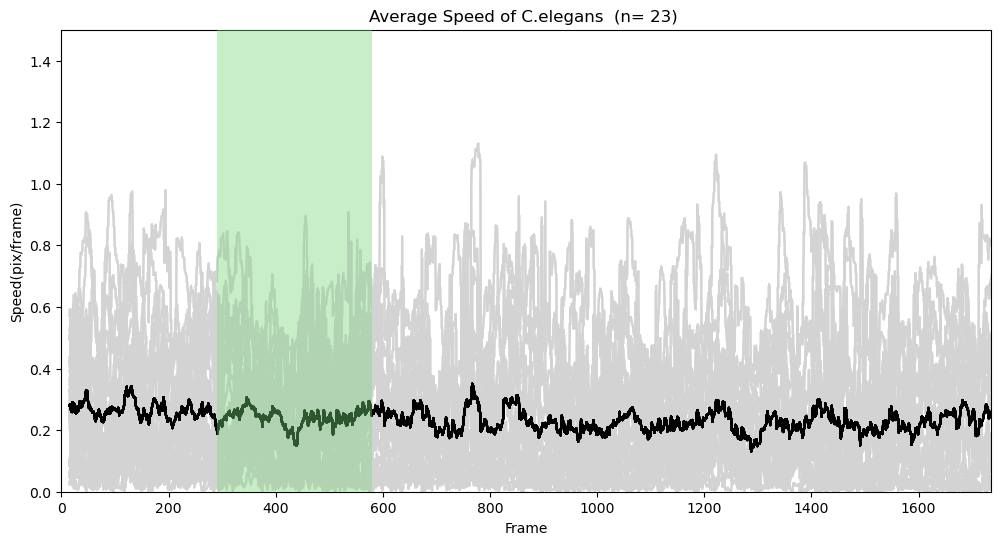

In [ ]:
#fig, axes = plt.subplots(2, 1, figsize = (5, 7.5), gridspec_kw={'height_ratios': [3, 1]})
fig, ax = plt.subplots(figsize=(12, 6))

for i in range(len(tott.columns)):
    plt.plot(tott['frame'], tott.filter(regex = "meanSpeed_.*"), 'lightgray', alpha = 0.07, zorder=1)
    plt.plot(tott['frame'], tott['all'], 'black', zorder=2)
    rectangle = plt.Rectangle((290,0), 290, 1.5, fc='lightgreen', alpha = 0.02, zorder=3)
    plt.gca().add_patch(rectangle)
    ax.set_ylim([0,1.5])
    ax.set_xlim(0,1736)
    ax.set_xlabel('Frame')    
    ax.set_ylabel('Speed(pix/frame)')
    ax.set_title('Average Speed of C.elegans  (n= ' + str(len(trainingList)) + ") " )

fig.savefig(os.path.join(Path, 'images',  'avgSpeedPlot.png'), dpi = 300)
fig.savefig(os.path.join(Path, 'images',  'avgSpeedPlot.svg'))

# average over seconds

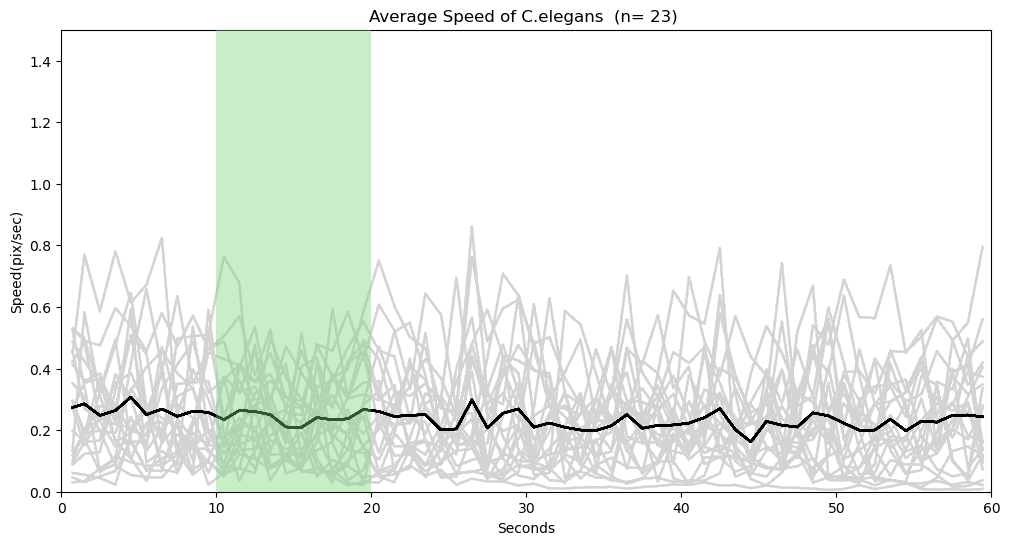

In [ ]:
data = tott.iloc[14:, :].reset_index(drop=True)
final = data.groupby(np.arange(len(data))//29).mean()

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(len(tott.columns)):
    plt.plot(final['second'], final.filter(regex = "meanSpeed_.*"), 'lightgray', alpha = 0.07, zorder=1)
    plt.plot(final['second'], final['all'], 'black', zorder=2)
    rectangle = plt.Rectangle((10,0), 10, 1.5, fc='lightgreen', alpha = 0.02, zorder=3)
    plt.gca().add_patch(rectangle)
    ax.set_ylim([0,1.5])
    ax.set_xlim(0,60)
    ax.set_xlabel('Seconds')    
    ax.set_ylabel('Speed(pix/sec)')
    ax.set_title('Average Speed of C.elegans  (n= ' + str(len(trainingList)) + ") " )

# fig.savefig(os.path.join(Path, 'images',  'avgSpeedPlot.png'), dpi = 300)
# fig.savefig(os.path.join(Path, 'images',  'avgSpeedPlot.svg'))